In [1]:
!pip install databricks-sql-connector pandas numpy scikit-learn matplotlib seaborn plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.4 MB/s eta 0:00:00
  Created wheel for thrift: filename=thrift-0.22.0-cp312-cp312-linux_x86_64.whl size=413532 sha256=de1958300748c9001a866cbe0008ea30512aa1a00cac8cf173e5dbba43196d10
  Stored in directory: /root/.cache/pip/wheels/03/30/a2/6e53de46f9d8f098a6b7c4a57dbdcafa5f11e87274e139f50b
Successfully built thrift


In [1]:
DATABRICKS_CONFIG = {
    'server_hostname': 'dbc-580abf4c-7d5c.cloud.databricks.com',
    'http_path': '/sql/1.0/warehouses/8041e0dc22a04da4',
    'access_token': 'YOUR_DATABRICKS_TOKEN_HERE'
}

🔗 Connecting to Databricks...
✅ Loaded 77 community areas

┘─ Sample Data:
   community_area_num   community_name  total_crimes  arrest_rate_pct  \
0                   1      ROGERS PARK        129092            27.92   
1                   2       WEST RIDGE         99964            17.57   
2                   3           UPTOWN        144980            34.84   
3                   4   LINCOLN SQUARE         57377            20.74   
4                   5     NORTH CENTER         61378            23.52   
5                   6        LAKE VIEW        204062            20.02   
6                   7     LINCOLN PARK        124639            15.06   
7                   8  NEAR NORTH SIDE        262741            29.84   
8                   9      EDISON PARK          4824            12.17   
9                  10     NORWOOD PARK         27773            14.95   

   domestic_pct  violent_pct  peak_crime_hour  yoy_change_pct  \
0          9.47        28.66               22          -

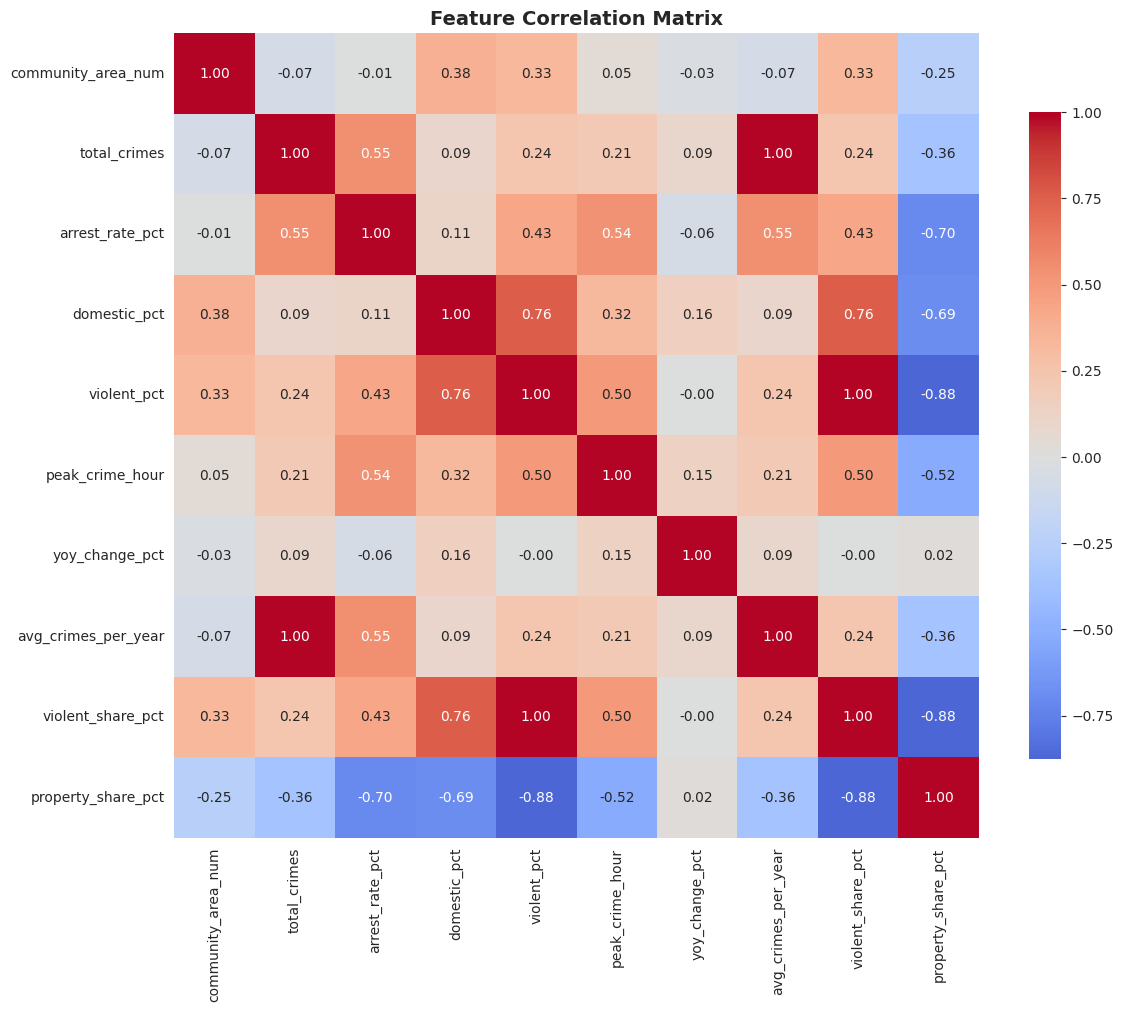

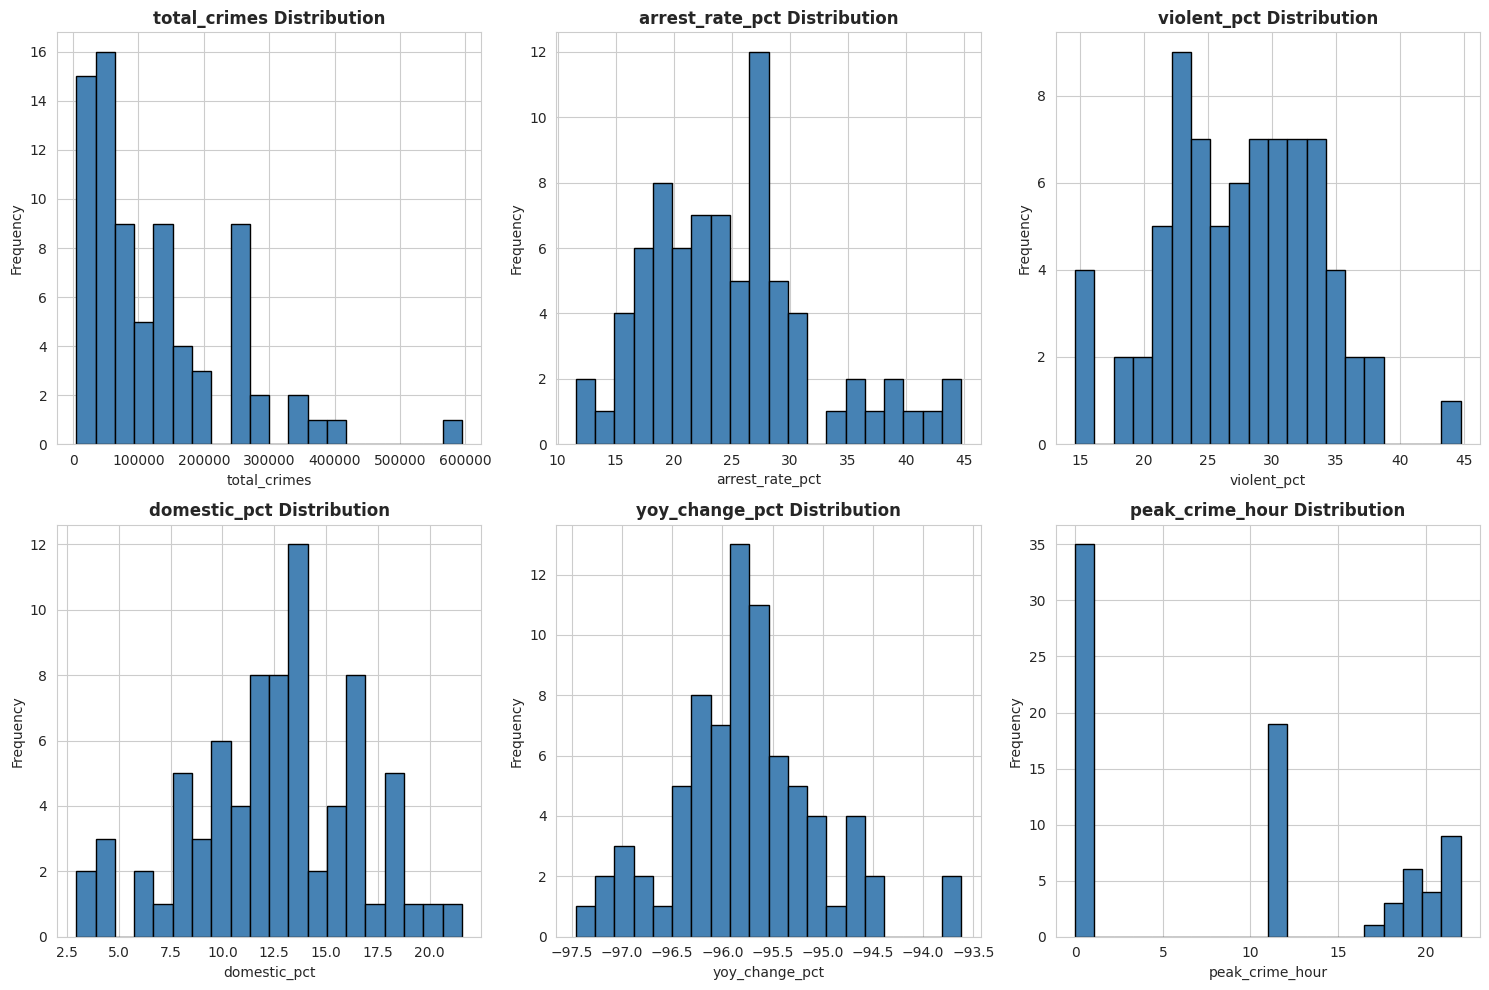


⚠️ Top 10 Highest Crime Communities:
        community_name  total_crimes  arrest_rate_pct  violent_pct
                AUSTIN        594864            43.16        30.35
         HUMBOLDT PARK        407523            39.21        30.50
        NEAR WEST SIDE        368450            27.28        23.85
             WEST TOWN        355833            19.35        21.90
             ENGLEWOOD        335353            29.37        38.30
              NEW CITY        289117            34.95        32.26
        WEST ENGLEWOOD        284083            30.76        36.17
GREATER GRAND CROSSING        266842            27.26        35.68
       NEAR NORTH SIDE        262741            29.84        21.11
          CHICAGO LAWN        262263            28.74        32.50

FEATURE SELECTION & SCALING

✅ Selected 9 features for clustering:
   • total_crimes
   • arrest_rate_pct
   • domestic_pct
   • violent_pct
   • peak_crime_hour
   • yoy_change_pct
   • avg_crimes_per_year
   • violent_shar

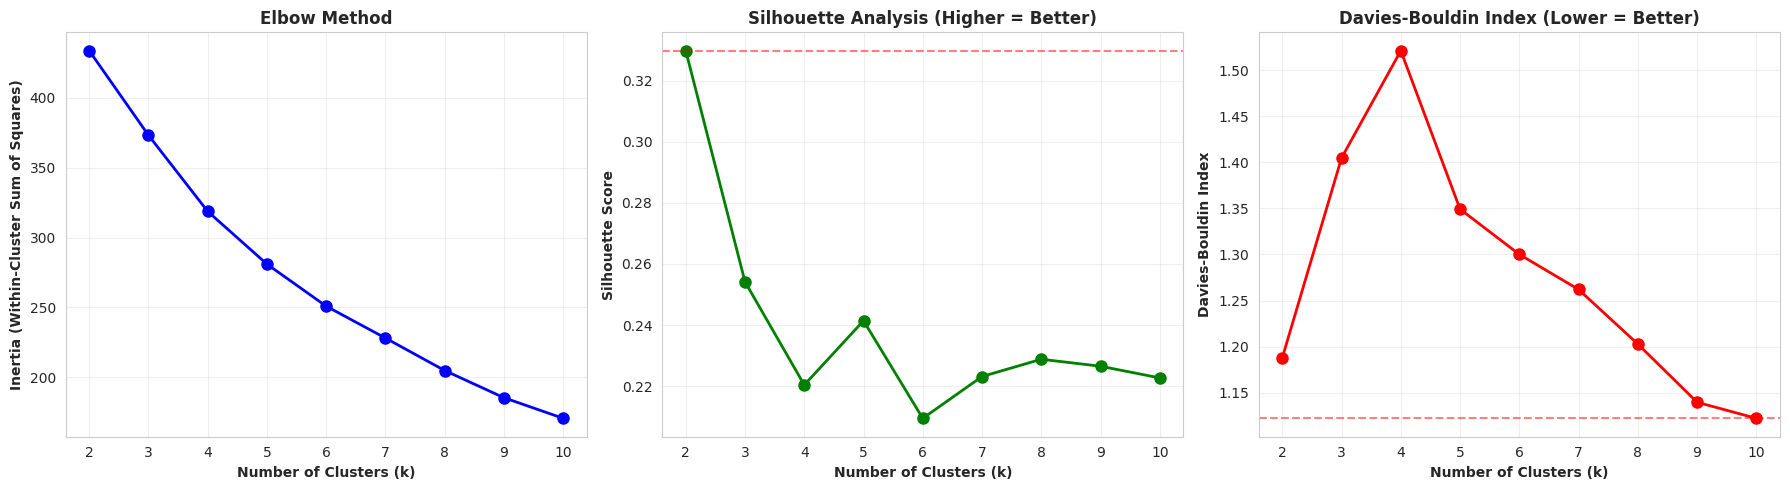


┘─ Clustering Metrics:
 k    Inertia  Silhouette  Davies-Bouldin
 2 433.742480    0.329784        1.187946
 3 373.209805    0.254166        1.404789
 4 318.679724    0.220420        1.521099
 5 280.926599    0.241430        1.349173
 6 250.806207    0.209497        1.300087
 7 227.975118    0.223177        1.261997
 8 204.745758    0.228832        1.202784
 9 185.293180    0.226546        1.139644
10 170.520082    0.222726        1.122152

✅ Recommended k based on Silhouette Score: 2
✅ Recommended k based on Davies-Bouldin: 10

K-MEANS CLUSTERING (k=4)

✅ Clustering complete!
┘─ Cluster distribution:
cluster
0    15
1    31
2    13
3    18
Name: count, dtype: int64

CLUSTER PROFILES

┘─ Mean Feature Values by Cluster:
         total_crimes  arrest_rate_pct  domestic_pct  violent_pct  peak_crime_hour  yoy_change_pct  avg_crimes_per_year  violent_share_pct  property_share_pct
cluster                                                                                                         


✅ PCA explains 71.3% of variance


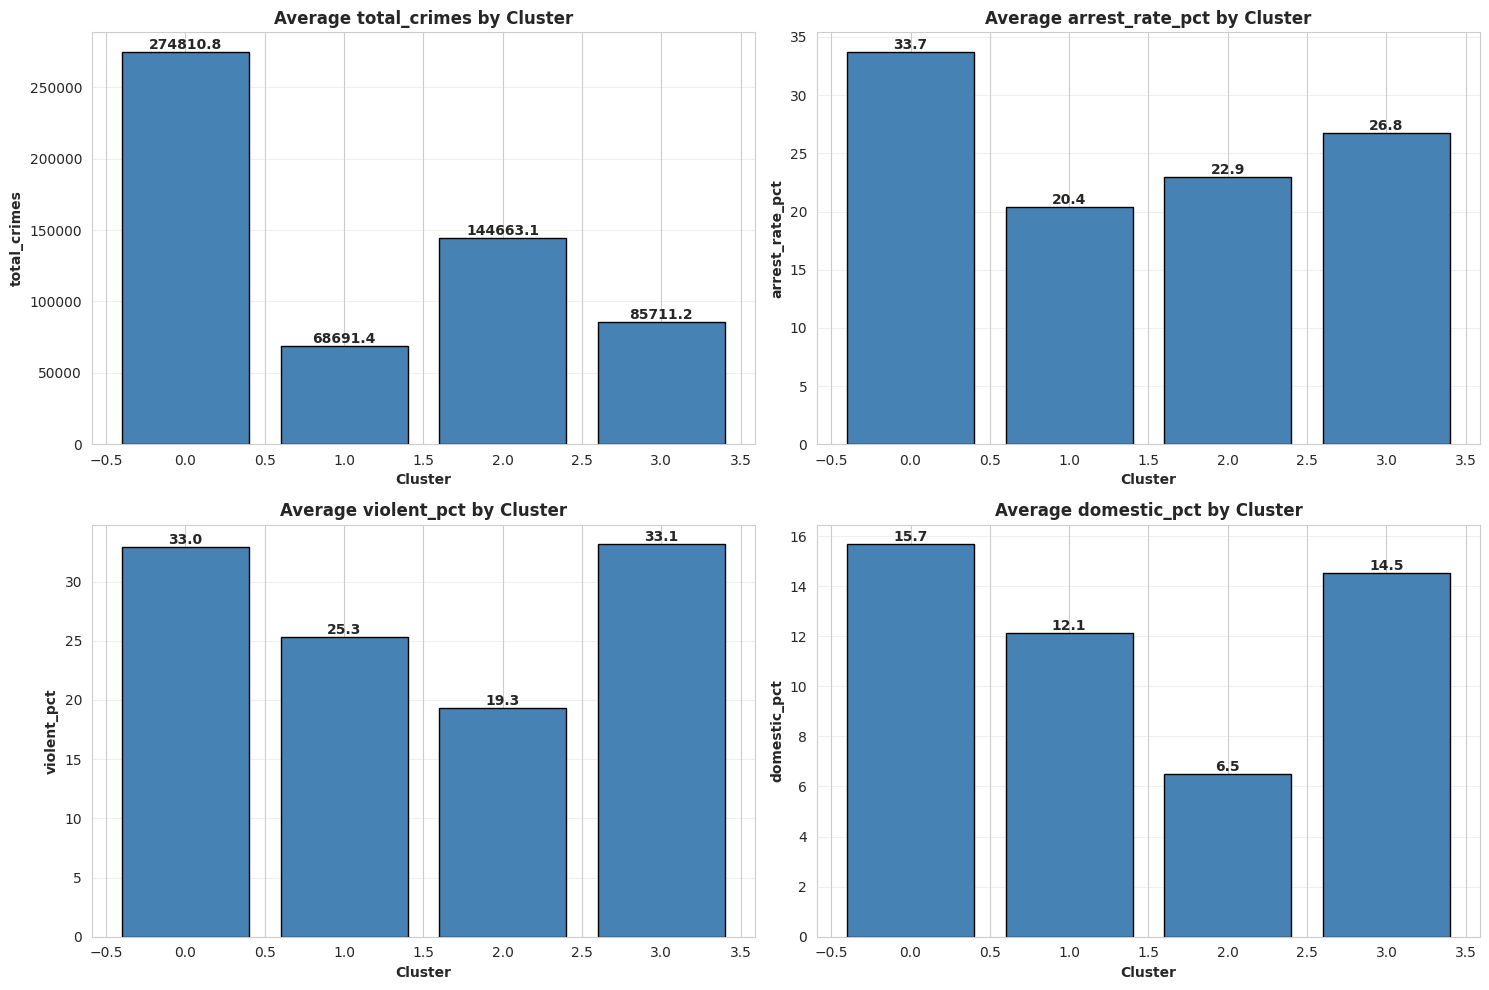

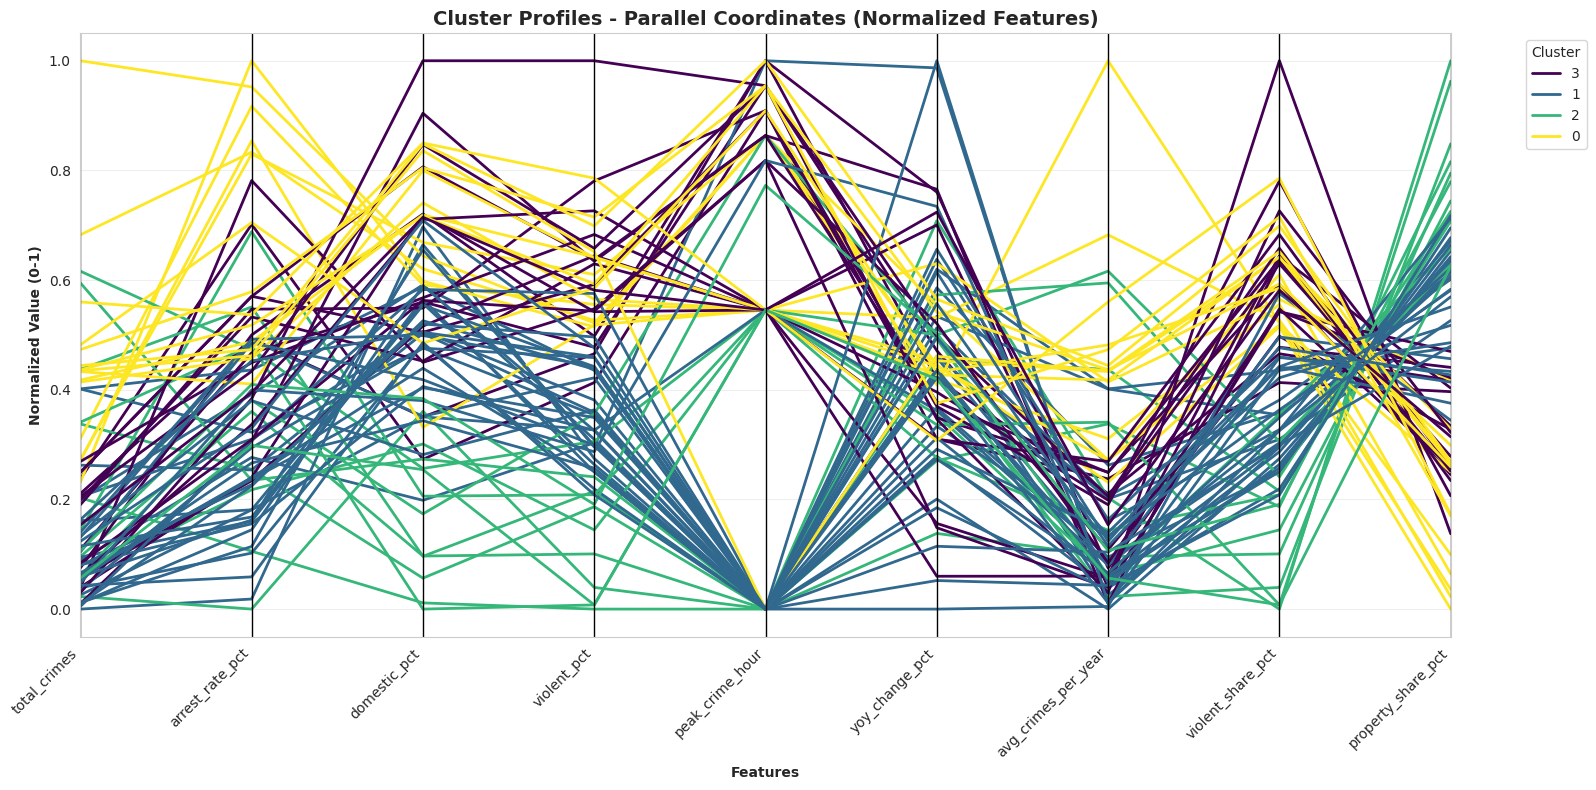

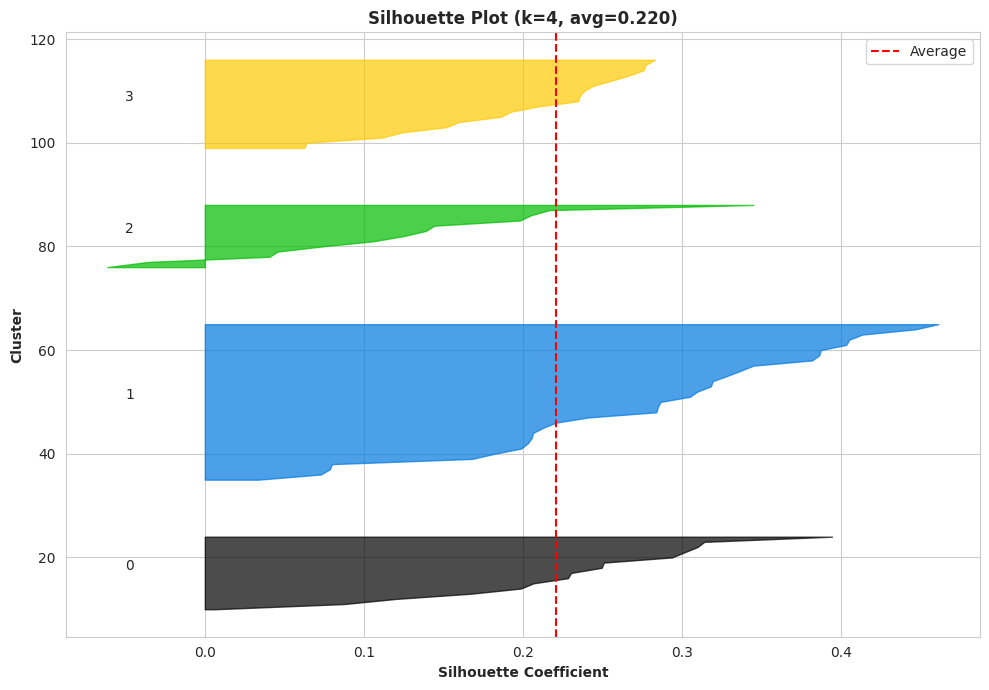


BUSINESS INSIGHTS & RECOMMENDATIONS

────────────────────────────────────────────────────────────────────────────────
CLUSTER 0: 15 Communities
────────────────────────────────────────────────────────────────────────────────
┘─ Profile: High Crime Volume | High Arrest Rate | High Violence

┐─ Key Characteristics:
   • Average Total Crimes: 274811
   • Average Arrest Rate: 33.7%
   • Violent Crime %: 33.0%
   • Domestic Crime %: 15.7%
   • YoY Change: -95.7%

ℹ️ Recommended Actions:
   ⚠️ High crime volume but adequate enforcement
      → Focus on root cause interventions (community programs, lighting, cameras)
   ⚠️ Elevated violent crime rate
      → Implement violence interruption programs
      → Increase community policing presence
   ╠ High domestic crime prevalence
      → Expand victim support services and hotlines
      → Partner with social services for intervention

╣ Top Communities (by crime volume):
      • AUSTIN: 594864 crimes, 43.2% arrest rate
      • HUMBOLDT PARK: 4

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# ═════════════════════════════════════════════════════════
# SECTION 2: DATABRICKS CONNECTION & DATA LOADING
# ═════════════════════════════════════════════════════════

from databricks import sql

# Databricks connection parameters
# IMPORTANT: Replace these with your Databricks workspace credentials
DATABRICKS_CONFIG = {
    'server_hostname': 'dbc-580abf4c-7d5c.cloud.databricks.com',
    'http_path': '/sql/1.0/warehouses/8041e0dc22a04da4',
    'access_token': 'YOUR_DATABRICKS_TOKEN_HERE'
}

def load_data_from_databricks():
    """
    Load ml_community_features from Databricks using SQL connector.

    Returns:
        pd.DataFrame: Community-level crime features (77 rows)
    """
    print("🔗 Connecting to Databricks...")

    connection = sql.connect(
        server_hostname=DATABRICKS_CONFIG['server_hostname'],
        http_path=DATABRICKS_CONFIG['http_path'],
        access_token=DATABRICKS_CONFIG['access_token']
    )

    query = """
    SELECT
        community_area_num,
        community_name,
        total_crimes,
        arrest_rate_pct,
        domestic_pct,
        violent_pct,
        peak_crime_hour,
        yoy_change_pct,
        avg_crimes_per_year,
        violent_share_pct,
        property_share_pct,
        is_high_volume_area,
        is_low_arrest_area,
        is_high_violent_area
    FROM chicago_crimes_workspace.gold.ml_community_features
    ORDER BY community_area_num
    """

    cursor = connection.cursor()
    cursor.execute(query)

    # Fetch results and convert to DataFrame
    columns = [desc[0] for desc in cursor.description]
    data = cursor.fetchall()
    df = pd.DataFrame(data, columns=columns)

    cursor.close()
    connection.close()

    print(f"✅ Loaded {len(df)} community areas")
    return df

# Load data
df_communities = load_data_from_databricks()

# Convert relevant columns to numeric type
# The traceback indicates issues with arithmetic operations, suggesting 'object' dtype columns
# containing Decimal objects need conversion to float.
numeric_cols_to_convert = [
    'arrest_rate_pct',
    'domestic_pct',
    'violent_pct',
    'yoy_change_pct',
    'avg_crimes_per_year',
    'violent_share_pct',
    'property_share_pct'
]

for col in numeric_cols_to_convert:
    if col in df_communities.columns and df_communities[col].dtype == 'object':
        df_communities[col] = pd.to_numeric(df_communities[col], errors='coerce')


# Display sample
print("\n┘─ Sample Data:")
print(df_communities.head(10))
print("\n┐─ Dataset Shape:", df_communities.shape)
print("\n└─ Data Types:")
print(df_communities.dtypes)

# ═════════════════════════════════════════════════════════
# SECTION 3: EXPLORATORY DATA ANALYSIS
# ═════════════════════════════════════════════════════════

def perform_eda(df):
    """Generate exploratory data analysis visualizations."""

    print("\n" + "="*80)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*80)

    # Summary statistics
    print("\n┘─ Descriptive Statistics:")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print(df[numeric_cols].describe().round(2))

    # Missing values check
    print("\n└─ Missing Values:")
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("✅ No missing values detected")
    else:
        print(missing[missing > 0])

    # Correlation heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    correlation = df[numeric_cols].corr()
    sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
    plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Distribution of key features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    key_features = ['total_crimes', 'arrest_rate_pct', 'violent_pct',
                    'domestic_pct', 'yoy_change_pct', 'peak_crime_hour']

    for idx, feature in enumerate(key_features):
        ax = axes[idx // 3, idx % 3]
        df[feature].hist(bins=20, ax=ax, color='steelblue', edgecolor='black')
        ax.set_title(f'{feature} Distribution', fontweight='bold')
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Top 10 highest crime communities
    top10 = df.nlargest(10, 'total_crimes')[['community_name', 'total_crimes',
                                              'arrest_rate_pct', 'violent_pct']]
    print("\n⚠️ Top 10 Highest Crime Communities:")
    print(top10.to_string(index=False))

    return correlation

correlation_matrix = perform_eda(df_communities)

# ═════════════════════════════════════════════════════════
# SECTION 4: FEATURE ENGINEERING & PREPROCESSING
# ═════════════════════════════════════════════════════════

# Select clustering features (exclude identifiers and binary flags)
clustering_features = [
    'total_crimes',
    'arrest_rate_pct',
    'domestic_pct',
    'violent_pct',
    'peak_crime_hour',
    'yoy_change_pct',
    'avg_crimes_per_year',
    'violent_share_pct',
    'property_share_pct'
]

print("\n" + "="*80)
print("FEATURE SELECTION & SCALING")
print("="*80)
print(f"\n✅ Selected {len(clustering_features)} features for clustering:")
for f in clustering_features:
    print(f"   • {f}")

# Extract feature matrix
X = df_communities[clustering_features].values

# Handle any remaining missing values (impute with median)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n┘─ Feature Matrix Shape: {X_scaled.shape}")
print(f"✅ Features standardized (mean=0, std=1)")

# ═════════════════════════════════════════════════════════
# SECTION 5: OPTIMAL CLUSTER SELECTION
# ═════════════════════════════════════════════════════════

def find_optimal_clusters(X, max_k=10):
    """
    Use Elbow Method, Silhouette Analysis, and Davies-Bouldin Index
    to determine optimal number of clusters.
    """

    print("\n" + "="*80)
    print("OPTIMAL CLUSTER SELECTION")
    print("="*80)

    K_range = range(2, max_k + 1)
    inertias = []
    silhouette_scores = []
    davies_bouldin_scores = []

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)

        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))
        davies_bouldin_scores.append(davies_bouldin_score(X, kmeans.labels_))

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Elbow Method
    axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Clusters (k)', fontweight='bold')
    axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontweight='bold')
    axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Silhouette Score (higher is better)
    axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Clusters (k)', fontweight='bold')
    axes[1].set_ylabel('Silhouette Score', fontweight='bold')
    axes[1].set_title('Silhouette Analysis (Higher = Better)', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=max(silhouette_scores), color='r', linestyle='--', alpha=0.5)

    # Davies-Bouldin Index (lower is better)
    axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
    axes[2].set_xlabel('Number of Clusters (k)', fontweight='bold')
    axes[2].set_ylabel('Davies-Bouldin Index', fontweight='bold')
    axes[2].set_title('Davies-Bouldin Index (Lower = Better)', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=min(davies_bouldin_scores), color='r', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Print metrics
    print("\n┘─ Clustering Metrics:")
    metrics_df = pd.DataFrame({
        'k': list(K_range),
        'Inertia': inertias,
        'Silhouette': silhouette_scores,
        'Davies-Bouldin': davies_bouldin_scores
    })
    print(metrics_df.to_string(index=False))

    # Recommend optimal k
    optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
    optimal_k_db = K_range[np.argmin(davies_bouldin_scores)]

    print(f"\n✅ Recommended k based on Silhouette Score: {optimal_k_silhouette}")
    print(f"✅ Recommended k based on Davies-Bouldin: {optimal_k_db}")

    return optimal_k_silhouette

optimal_k = find_optimal_clusters(X_scaled, max_k=10)

# ═════════════════════════════════════════════════════════
# SECTION 6: K-MEANS CLUSTERING
# ═════════════════════════════════════════════════════════

# Apply K-Means with optimal k (or manually set k=4 or k=5 if preferred)
k_final = 4  # You can override this: k_final = 4

print("\n" + "="*80)
print(f"K-MEANS CLUSTERING (k={k_final})")
print("="*80)

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=20, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_communities['cluster'] = cluster_labels

print(f"\n✅ Clustering complete!")
print(f"┘─ Cluster distribution:")
print(df_communities['cluster'].value_counts().sort_index())

# ═════════════════════════════════════════════════════════
# SECTION 7: CLUSTER PROFILING & INTERPRETATION
# ═════════════════════════════════════════════════════════

def profile_clusters(df, features):
    """Generate cluster profiles with mean characteristics."""

    print("\n" + "="*80)
    print("CLUSTER PROFILES")
    print("="*80)

    cluster_profiles = df.groupby('cluster')[features].mean().round(2)

    print("\n┘─ Mean Feature Values by Cluster:")
    print(cluster_profiles.to_string())

    # Count by cluster
    print("\n┐─ Community Count by Cluster:")
    cluster_counts = df.groupby('cluster').size()
    for cluster_id, count in cluster_counts.items():
        print(f"   Cluster {cluster_id}: {count} communities")

    # Show example communities per cluster
    print("\n└─ Example Communities by Cluster:")
    for cluster_id in sorted(df['cluster'].unique()):
        examples = df[df['cluster'] == cluster_id].nlargest(3, 'total_crimes')[['community_name', 'total_crimes']]
        print(f"\n   Cluster {cluster_id}:")
        for _, row in examples.iterrows():
            print(f"      • {row['community_name']} ({row['total_crimes']} crimes)")

    return cluster_profiles

cluster_profiles = profile_clusters(df_communities, clustering_features)

# ═════════════════════════════════════════════════════════
# SECTION 8: VISUALIZATIONS
# ═════════════════════════════════════════════════════════

# 1. PCA Visualization (2D)
print("\n" + "="*80)
print("VISUALIZATIONS")
print("="*80)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = df_communities.copy()
df_pca['PC1'] = X_pca[:, 0]
df_pca['PC2'] = X_pca[:, 1]

fig = px.scatter(
    df_pca,
    x='PC1',
    y='PC2',
    color='cluster',
    hover_data=['community_name', 'total_crimes', 'arrest_rate_pct', 'violent_pct'],
    title=f'K-Means Clusters (k={k_final}) - PCA Visualization',
    labels={'cluster': 'Cluster'},
    color_continuous_scale='viridis'
)
fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(height=600, font=dict(size=12))
fig.show()

print(f"\n✅ PCA explains {pca.explained_variance_ratio_.sum()*100:.1f}% of variance")

# 2. Cluster comparison - key metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['total_crimes', 'arrest_rate_pct', 'violent_pct', 'domestic_pct']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    cluster_means = df_communities.groupby('cluster')[metric].mean().sort_index()
    bars = ax.bar(cluster_means.index, cluster_means.values, color='steelblue', edgecolor='black')
    ax.set_xlabel('Cluster', fontweight='bold')
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_title(f'Average {metric} by Cluster', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Parallel Coordinates Plot
from pandas.plotting import parallel_coordinates

# Normalize features for visualization
df_viz = df_communities[['cluster'] + clustering_features].copy()
for col in clustering_features:
    df_viz[col] = (df_viz[col] - df_viz[col].min()) / (df_viz[col].max() - df_viz[col].min())

df_viz['cluster'] = df_viz['cluster'].astype(str)

plt.figure(figsize=(16, 8))
parallel_coordinates(df_viz, 'cluster', colormap='viridis', linewidth=2)
plt.title('Cluster Profiles - Parallel Coordinates (Normalized Features)', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontweight='bold')
plt.ylabel('Normalized Value (0-1)', fontweight='bold')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Silhouette plot for final clustering
from matplotlib import cm

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
silhouette_avg = silhouette_score(X_scaled, cluster_labels)

for i in range(k_final):
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    cluster_silhouette_vals.sort()

    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / k_final)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.set_title(f'Silhouette Plot (k={k_final}, avg={silhouette_avg:.3f})', fontweight='bold')
ax.set_xlabel('Silhouette Coefficient', fontweight='bold')
ax.set_ylabel('Cluster', fontweight='bold')
ax.axvline(x=silhouette_avg, color='red', linestyle='--', label='Average')
ax.legend()
plt.tight_layout()
plt.show()

# ═════════════════════════════════════════════════════════
# SECTION 9: BUSINESS INSIGHTS & RECOMMENDATIONS
# ═════════════════════════════════════════════════════════

def generate_insights(df, profiles):
    """Generate actionable business insights from cluster analysis."""

    print("\n" + "="*80)
    print("BUSINESS INSIGHTS & RECOMMENDATIONS")
    print("="*80)

    for cluster_id in sorted(df['cluster'].unique()):
        cluster_data = df[df['cluster'] == cluster_id]
        profile = profiles.loc[cluster_id]

        print(f"\n{'\u2500'*80}")
        print(f"CLUSTER {cluster_id}: {len(cluster_data)} Communities")
        print(f"{'\u2500'*80}")

        # Characterize cluster
        crime_level = "High" if profile['total_crimes'] > df['total_crimes'].median() else "Low"
        arrest_level = "High" if profile['arrest_rate_pct'] > df['arrest_rate_pct'].median() else "Low"
        violent_level = "High" if profile['violent_pct'] > df['violent_pct'].median() else "Low"

        print(f"┘─ Profile: {crime_level} Crime Volume | {arrest_level} Arrest Rate | {violent_level} Violence")
        print(f"\n┐─ Key Characteristics:")
        print(f"   • Average Total Crimes: {profile['total_crimes']:.0f}")
        print(f"   • Average Arrest Rate: {profile['arrest_rate_pct']:.1f}%")
        print(f"   • Violent Crime %: {profile['violent_pct']:.1f}%")
        print(f"   • Domestic Crime %: {profile['domestic_pct']:.1f}%")
        print(f"   • YoY Change: {profile['yoy_change_pct']:.1f}%")

        # Recommendations
        print(f"\nℹ️ Recommended Actions:")

        if profile['total_crimes'] > df['total_crimes'].quantile(0.75):
            if profile['arrest_rate_pct'] < df['arrest_rate_pct'].quantile(0.25):
                print("   ⚠️ CRITICAL: High crime volume + low arrest rate")
                print("      → Deploy additional patrol units and investigative resources")
                print("      → Review case assignment and follow-through procedures")
            else:
                print("   ⚠️ High crime volume but adequate enforcement")
                print("      → Focus on root cause interventions (community programs, lighting, cameras)")

        if profile['violent_pct'] > df['violent_pct'].quantile(0.75):
            print("   ⚠️ Elevated violent crime rate")
            print("      → Implement violence interruption programs")
            print("      → Increase community policing presence")

        if profile['domestic_pct'] > df['domestic_pct'].quantile(0.75):
            print("   ╠ High domestic crime prevalence")
            print("      → Expand victim support services and hotlines")
            print("      → Partner with social services for intervention")

        if profile['yoy_change_pct'] > 5:
            print("   ┐ Rising crime trend (>5% YoY)")
            print("      → Conduct tactical analysis to identify emerging patterns")
            print("      → Consider targeted intervention pilots")

        # List top 5 communities in cluster
        top_communities = cluster_data.nlargest(5, 'total_crimes')[['community_name', 'total_crimes', 'arrest_rate_pct']]
        print(f"\n╣ Top Communities (by crime volume):")
        for _, row in top_communities.iterrows():
            print(f"      • {row['community_name']}: {row['total_crimes']:.0f} crimes, {row['arrest_rate_pct']:.1f}% arrest rate")

    # Overall summary
    print(f"\n\n{'\u2550'*80}")
    print("SUMMARY")
    print(f"{'\u2550'*80}")
    print(f"✅ Successfully clustered 77 Chicago communities into {k_final} groups")
    print(f"✅ Clusters reveal distinct crime-enforcement profiles")
    print(f"✅ Resource allocation should prioritize high-volume + low-arrest clusters")
    print(f"✅ Domestic and violent crime hotspots require specialized interventions")

generate_insights(df_communities, cluster_profiles)

# ═════════════════════════════════════════════════════════
# SECTION 10: EXPORT RESULTS
# ═════════════════════════════════════════════════════════

# Save clustered data to CSV
output_file = 'chicago_community_clusters.csv'
df_communities.to_csv(output_file, index=False)
print(f"\n\n╣ Results saved to: {output_file}")

# Save cluster profiles
profile_file = 'cluster_profiles_summary.csv'
cluster_profiles.to_csv(profile_file)
print(f"╣ Cluster profiles saved to: {profile_file}")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)
